Practice 1

1. Refit LogisticRegression (notebook 2) using only the 5 features with strongest correlation to the target. Compare accuracy, precision, and recall to the full 30-feature model. Was dropping 25 features costly? Plot both models' three metrics as a grouped bar chart, same style as section 3.

Cell 1

In [1]:
# Bring your tools before starting the job.

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score , precision_score , recall_score)

Cell 2

In [2]:
# Always look at the data before building a model.

data = load_breast_cancer(as_frame=True)

df = data.frame

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Cell 3

In [3]:
# X is the question, y is the answer.

X = df.drop(columns="target")

y = df["target"]

Cell 4

In [4]:
# Higher correlation means higher importance.

corr_with_target = (df.drop(columns="target").corrwith(df["target"]).abs().sort_values(ascending=False))

corr_with_target.head(10)

worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
dtype: float64

Cell 5

In [5]:
# Keep the strongest features first.

top5_features = ["worst concave points","worst perimeter","mean concave points","worst radius","mean perimeter"]

top5_features

['worst concave points',
 'worst perimeter',
 'mean concave points',
 'worst radius',
 'mean perimeter']

Call 6

In [6]:
# Train on one part, test on another part.

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

Cell 7

In [7]:
# Less features, simpler model.

X_train5 = X_train[top5_features]
X_test5 = X_test[top5_features]

print(X_train5.shape)
print(X_test5.shape)

(455, 5)
(114, 5)


Cell 8

In [8]:
# Fit on train, transform everywhere.

scaler_full = StandardScaler()

X_train_scaled = scaler_full.fit_transform(X_train)
X_test_scaled = scaler_full.transform(X_test)

Cell 9

In [9]:
# Train first, predict later.

logreg_full = LogisticRegression(max_iter=5000)

logreg_full.fit(X_train_scaled,y_train)

y_pred_full = logreg_full.predict(X_test_scaled)

Cell 10

In [10]:
# Measure before comparing.

acc_full = accuracy_score(y_test,y_pred_full)

prec_full = precision_score(y_test,y_pred_full)

rec_full = recall_score(y_test,y_pred_full)

print(f"acc_full : {acc_full}")
print(f"prec_full : {prec_full}")
print(f"rec_full : {rec_full}")

acc_full : 0.9824561403508771
prec_full : 0.9861111111111112
rec_full : 0.9861111111111112


Cell 11

In [11]:
# Same process, fewer features.

scaler_5 = StandardScaler()

X_train5_scaled = scaler_5.fit_transform(X_train5)

X_test5_scaled = scaler_5.transform(X_test5)

Cell 12

In [12]:
# Build the smaller model.

logreg_5 = LogisticRegression(max_iter=5000)

logreg_5.fit(X_train5_scaled,y_train)

y_pred_5 = logreg_5.predict(X_test5_scaled)

Cell 13

In [13]:
# Score the small model too.

acc_5 = accuracy_score(y_test,y_pred_5)

prec_5 = precision_score(y_test,y_pred_5)

rec_5 = recall_score(y_test,y_pred_5)

print(f"acc_5 : {acc_5}")
print(f"prec_5 : {prec_5}")
print(f"rec_5 : {rec_5}")

acc_5 : 0.9385964912280702
prec_5 : 0.9710144927536232
rec_5 : 0.9305555555555556


Cell 14

In [14]:
# Organize before comparing.

comparison = pd.DataFrame({"Metric": ["Accuracy","Precision","Recall"],
"Full Model": [acc_full,prec_full,rec_full],
"Top 5 Features": [acc_5,prec_5,rec_5]})

print(comparison)

      Metric  Full Model  Top 5 Features
0   Accuracy    0.982456        0.938596
1  Precision    0.986111        0.971014
2     Recall    0.986111        0.930556


Cell 15

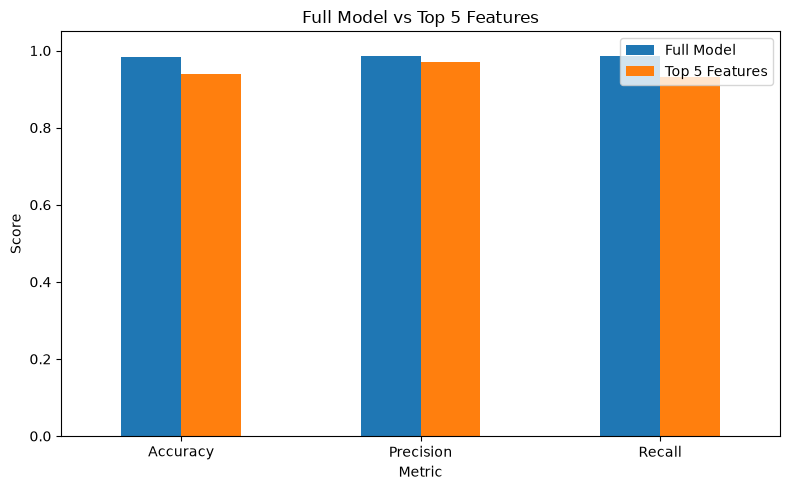

In [15]:
# Visualize the comparison.

comparison.set_index("Metric").plot( kind="bar",figsize=(8,5))

plt.title("Full Model vs Top 5 Features")

plt.ylabel("Score")

plt.ylim(0,1.05)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

Cell 16

In [16]:
# Summarize the final result.

print("Full Model")
print("Accuracy :", round(acc_full,4))
print("Precision:", round(prec_full,4))
print("Recall   :", round(rec_full,4))

print("-" * 30)

print("Top 5 Features")
print("Accuracy :", round(acc_5,4))
print("Precision:", round(prec_5,4))
print("Recall   :", round(rec_5,4))

Full Model
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
------------------------------
Top 5 Features
Accuracy : 0.9386
Precision: 0.971
Recall   : 0.9306
